In [1]:
# Install libraries
!pip install -q pymupdf
!pip install -q sentence-transformers
!pip install -q transformers
!pip install -q accelerate
!pip install -q faiss-cpu
!pip install -q nltk

In [2]:
# Imports

import os
import json
import re
import zipfile

import fitz
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm

import nltk
nltk.download("punkt")

from nltk.tokenize import sent_tokenize

from google.colab import drive
drive.mount("/content/drive")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Directory configuration
ZIP_FILE = "/content/drive/MyDrive/5.SemanticMapping/ESG_KB.zip"

ROOT = "/content/ESG_KB"

if not os.path.exists(ROOT):

    with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
        zip_ref.extractall("/content")

    print("Extracted ESG_KB.zip")

PDF_DIR = os.path.join(
    ROOT
)

OUTPUT_DIR = "/content/drive/MyDrive/5.SemanticMapping/output"

FAISS_DIR = "/content/drive/MyDrive/5.SemanticMapping/faiss"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FAISS_DIR, exist_ok=True)

RAW_DOCUMENT_FILE = os.path.join(
    OUTPUT_DIR,
    "raw_documents.json"
)

print(PDF_DIR)
print(OUTPUT_DIR)
print(FAISS_DIR)

/content/ESG_KB
/content/drive/MyDrive/5.SemanticMapping/output
/content/drive/MyDrive/5.SemanticMapping/faiss


In [4]:
# Scan PDF files

pdf_files = sorted(

    list(

        Path(PDF_DIR).glob("*.pdf")

    )

)

print(f"Found {len(pdf_files)} PDF files\n")

for pdf in pdf_files:

    print(pdf.name)

Found 43 PDF files

GRI 101_ Biodiversity 2024 - English.pdf
GRI 102_ Climate Change 2025.pdf
GRI 103_ Energy 2025.pdf
GRI 11_ Oil and Gas Sector 2021 V1.1.pdf
GRI 12_ Coal Sector 2022 V1.1.pdf
GRI 13_ Agriculture Aquaculture and Fishing Sectors 2022 V1.1.pdf
GRI 14_ Mining Sector 2024 V1.1.pdf
GRI 1_ Foundation 2021.pdf
GRI 201_  Economic Performance 2016.pdf
GRI 202_ Market Presence 2016.pdf
GRI 203_ Indirect Economic Impacts 2016.pdf
GRI 204_ Procurement Practices 2016.pdf
GRI 205_ Anti-corruption 2016.pdf
GRI 206_ Anti-competitive Behavior 2016.pdf
GRI 207_ Tax 2019.pdf
GRI 2_ General Disclosures 2021.pdf
GRI 301_ Materials 2016.pdf
GRI 302_ Energy 2016.pdf
GRI 303_ Water and Effluents 2018.pdf
GRI 305_ Emissions 2016.pdf
GRI 306_ Effluents and Waste 2016.pdf
GRI 306_ Waste 2020.pdf
GRI 308_ Supplier Environmental Assessment 2016.pdf
GRI 3_ Material Topics 2021.pdf
GRI 401_ Employment 2016.pdf
GRI 402_ Labor and Management Relations 2016.pdf
GRI 403_ Occupational Health and Safety 

In [5]:
# Extract text from PDFs

documents = []

for pdf_path in tqdm(pdf_files):

    doc = fitz.open(pdf_path)

    pages = []

    for page_id in range(len(doc)):

        page = doc.load_page(page_id)

        text = page.get_text("text")

        text = text.replace("\xa0", " ")

        text = re.sub(r"\s+", " ", text)

        pages.append({

            "page": page_id + 1,

            "text": text.strip()

        })

    documents.append({

        "document":

            pdf_path.stem,

        "file":

            pdf_path.name,

        "num_pages":

            len(doc),

        "pages":

            pages

    })

print(f"\nLoaded {len(documents)} documents")

  0%|          | 0/43 [00:00<?, ?it/s]


Loaded 43 documents


In [6]:
# Build document metadata

metadata = []

for doc in documents:

    metadata.append({

        "document":

            doc["document"],

        "file":

            doc["file"],

        "num_pages":

            doc["num_pages"],

        "standard":

            doc["document"].split("_")[0],

        "title":

            doc["document"]

    })

print(pd.DataFrame(metadata))

                                             document  \
0                GRI 101_ Biodiversity 2024 - English   
1                        GRI 102_ Climate Change 2025   
2                                GRI 103_ Energy 2025   
3                GRI 11_ Oil and Gas Sector 2021 V1.1   
4                       GRI 12_ Coal Sector 2022 V1.1   
5   GRI 13_ Agriculture Aquaculture and Fishing Se...   
6                     GRI 14_ Mining Sector 2024 V1.1   
7                              GRI 1_ Foundation 2021   
8                 GRI 201_  Economic Performance 2016   
9                       GRI 202_ Market Presence 2016   
10            GRI 203_ Indirect Economic Impacts 2016   
11                GRI 204_ Procurement Practices 2016   
12                      GRI 205_ Anti-corruption 2016   
13            GRI 206_ Anti-competitive Behavior 2016   
14                                  GRI 207_ Tax 2019   
15                    GRI 2_ General Disclosures 2021   
16                            G

In [7]:
# Save extracted documents

with open(
    RAW_DOCUMENT_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        documents,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Saved")

print(RAW_DOCUMENT_FILE)

Saved
/content/drive/MyDrive/5.SemanticMapping/output/raw_documents.json


In [8]:
# Clean document text

def clean_text(text):

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    # Remove page numbers (simple heuristic)
    text = re.sub(r"\b\d+\b(?=\s*$)", "", text)

    # Remove long underscore
    text = re.sub(r"_+", " ", text)

    # Remove duplicated punctuation
    text = re.sub(r"\.{2,}", ".", text)

    # Remove duplicated commas
    text = re.sub(r",{2,}", ",", text)

    # Remove duplicated semicolons
    text = re.sub(r";{2,}", ";", text)

    # Strip
    text = text.strip()

    return text


for doc in documents:

    for page in doc["pages"]:

        page["text"] = clean_text(page["text"])

print("Cleaning completed.")

Cleaning completed.


In [9]:
# RecursiveCharacterTextSplitter
!pip install -q langchain-text-splitters

from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE = 1200          # khoảng 250-350 tokens
CHUNK_OVERLAP = 200

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=[
        "\n\n",
        "\n",
        ". ",
        "; ",
        ", ",
        " "
    ]
)

def chunk_text(text):

    text = clean_text(text)

    chunks = splitter.split_text(text)

    return [
        chunk.strip()
        for chunk in chunks
        if len(chunk.strip()) > 0
    ]

print("RecursiveCharacterTextSplitter ready.")

RecursiveCharacterTextSplitter ready.


In [10]:
# Build ESG chunks

esg_chunks = []

chunk_id = 0

for doc in tqdm(documents):

    for page in doc["pages"]:

        page_chunks = chunk_text(page["text"])

        for local_id, chunk in enumerate(page_chunks):

            if len(chunk.split()) < 20:
                continue

            esg_chunks.append({

                "chunk_id": chunk_id,

                "document": doc["document"],

                "standard": doc["document"].split("_")[0],

                "page": page["page"],

                "local_chunk": local_id,

                "num_words": len(chunk.split()),

                "num_chars": len(chunk),

                "text": chunk

            })

            chunk_id += 1

print("=" * 60)
print(f"Total ESG chunks : {len(esg_chunks)}")
print("=" * 60)

  0%|          | 0/43 [00:00<?, ?it/s]

Total ESG chunks : 3456


In [11]:
# Save ESG chunks

CHUNK_FILE = os.path.join(
    OUTPUT_DIR,
    "esg_chunks.json"
)

with open(
    CHUNK_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        esg_chunks,
        f,
        ensure_ascii=False,
        indent=2
    )

print("=" * 60)
print(f"Saved {len(esg_chunks)} chunks")
print(CHUNK_FILE)
print("=" * 60)

Saved 3456 chunks
/content/drive/MyDrive/5.SemanticMapping/output/esg_chunks.json


In [12]:
# Inspect ESG chunks

print("=" * 80)
print(f"Total chunks : {len(esg_chunks)}")
print("=" * 80)

word_lengths = [c["num_words"] for c in esg_chunks]
char_lengths = [c["num_chars"] for c in esg_chunks]

print(f"Average words : {np.mean(word_lengths):.1f}")
print(f"Min words     : {np.min(word_lengths)}")
print(f"Max words     : {np.max(word_lengths)}")

print()

print(f"Average chars : {np.mean(char_lengths):.1f}")
print(f"Min chars     : {np.min(char_lengths)}")
print(f"Max chars     : {np.max(char_lengths)}")

print("=" * 80)

for sample in esg_chunks[:5]:

    print(f"\nChunk ID  : {sample['chunk_id']}")
    print(f"Document  : {sample['document']}")
    print(f"Standard  : {sample['standard']}")
    print(f"Page      : {sample['page']}")
    print(f"Words     : {sample['num_words']}")
    print(f"Chars     : {sample['num_chars']}")

    print("-" * 80)
    print(sample["text"][:700])
    print("-" * 80)

Total chunks : 3456
Average words : 135.1
Min words     : 20
Max words     : 276

Average chars : 925.2
Min chars     : 117
Max chars     : 1200

Chunk ID  : 0
Document  : GRI 101_ Biodiversity 2024 - English
Standard  : GRI 101
Page      : 2
Words     : 139
Chars     : 1038
--------------------------------------------------------------------------------
GRI 101: Biodiversity 2024 Topic Standard Effective Date This Standard is effective for reports or other materials published on or after 1 January 2026. Responsibility This Standard is issued by the Global Sustainability Standards Board (GSSB). Any feedback on the GRI Standards can be submitted to gssbsecretariat@globalreporting.org for the consideration of the GSSB. Due Process This Standard was developed in the public interest and in accordance with the requirements of the GSSB Due Process Protocol. It has been developed using multi-stakeholder expertise, and with regard to authoritative intergovernmental instruments and widely held 

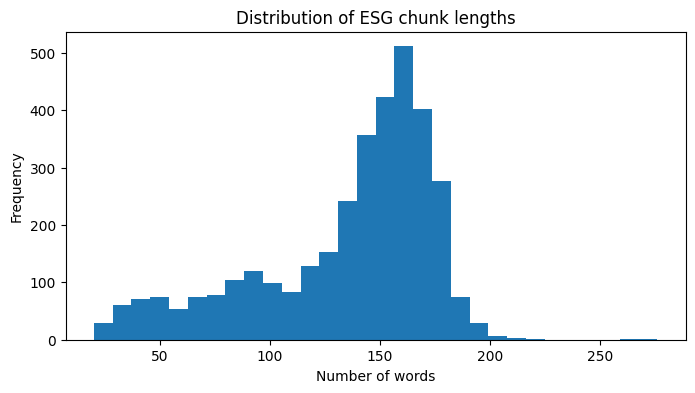

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(word_lengths, bins=30)

plt.xlabel("Number of words")

plt.ylabel("Frequency")

plt.title("Distribution of ESG chunk lengths")

plt.show()

In [15]:
# Load ClimateBERT

import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

MODEL_NAME = "climatebert/distilroberta-base-climate-f"

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModel.from_pretrained(MODEL_NAME)

model.to(device)

model.eval()

print("ClimateBERT loaded.")

Device: cuda


config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ClimateBERT loaded.


In [16]:
# Encode ESG chunks

BATCH_SIZE = 16

MAX_LENGTH = 256


def mean_pooling(model_output, attention_mask):

    token_embeddings = model_output.last_hidden_state

    mask = attention_mask.unsqueeze(-1).expand(

        token_embeddings.size()

    ).float()

    return torch.sum(

        token_embeddings * mask,

        dim=1

    ) / torch.clamp(

        mask.sum(dim=1),

        min=1e-9

    )


texts = [

    c["text"]

    for c in esg_chunks

]

embeddings = []

for i in tqdm(

        range(

            0,

            len(texts),

            BATCH_SIZE

        )

):

    batch = texts[

        i:i+BATCH_SIZE

    ]

    encoded = tokenizer(

        batch,

        padding=True,

        truncation=True,

        max_length=MAX_LENGTH,

        return_tensors="pt"

    )

    encoded = {

        k:v.to(device)

        for k,v in encoded.items()

    }

    with torch.no_grad():

        outputs = model(**encoded)

    emb = mean_pooling(

        outputs,

        encoded["attention_mask"]

    )

    emb = emb.cpu().numpy()

    embeddings.append(emb)

embeddings = np.vstack(embeddings)

print(embeddings.shape)

  0%|          | 0/216 [00:00<?, ?it/s]

(3456, 768)


In [17]:
# Save embeddings

EMBED_FILE = os.path.join(

    OUTPUT_DIR,

    "embeddings.npy"

)

np.save(

    EMBED_FILE,

    embeddings

)

print(

    "Saved:",

    EMBED_FILE

)

print(

    "Shape:",

    embeddings.shape

)

Saved: /content/drive/MyDrive/5.SemanticMapping/output/embeddings.npy
Shape: (3456, 768)


In [18]:
# Build FAISS Index

import faiss

# Normalize embeddings
embeddings = embeddings.astype(np.float32)

faiss.normalize_L2(embeddings)

dimension = embeddings.shape[1]

print("Embedding dimension :", dimension)

print("Number of chunks     :", embeddings.shape[0])

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("\nFAISS Index created.")

print("Total vectors :", index.ntotal)

Embedding dimension : 768
Number of chunks     : 3456

FAISS Index created.
Total vectors : 3456


In [19]:
# Save FAISS Index

INDEX_FILE = os.path.join(

    FAISS_DIR,

    "esg.index"

)

faiss.write_index(

    index,

    INDEX_FILE

)

print("Saved FAISS index")

print(INDEX_FILE)

Saved FAISS index
/content/drive/MyDrive/5.SemanticMapping/faiss/esg.index


In [20]:
# Save metadata

metadata = []

for chunk in esg_chunks:

    metadata.append({

        "chunk_id": chunk["chunk_id"],

        "document": chunk["document"],

        "standard": chunk["standard"],

        "page": chunk["page"],

        "local_chunk": chunk["local_chunk"],

        "num_words": chunk["num_words"],

        "text": chunk["text"]

    })

META_FILE = os.path.join(

    FAISS_DIR,

    "metadata.json"

)

with open(

    META_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        metadata,

        f,

        ensure_ascii=False,

        indent=2

    )

print("Saved metadata")

print(META_FILE)

print(f"Metadata entries : {len(metadata)}")

Saved metadata
/content/drive/MyDrive/5.SemanticMapping/faiss/metadata.json
Metadata entries : 3456


In [21]:
# Load ESG Knowledge Base

import faiss
import json
import numpy as np

INDEX_FILE = os.path.join(
    FAISS_DIR,
    "esg.index"
)

META_FILE = os.path.join(
    FAISS_DIR,
    "metadata.json"
)

index = faiss.read_index(INDEX_FILE)

with open(META_FILE, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("Knowledge Base loaded")

print("Vectors :", index.ntotal)
print("Metadata:", len(metadata))

Knowledge Base loaded
Vectors : 3456
Metadata: 3456


In [22]:
# Semantic Search

def encode_query(text):

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    encoded = {
        k: v.to(device)
        for k, v in encoded.items()
    }

    with torch.no_grad():
        outputs = model(**encoded)

    embedding = mean_pooling(
        outputs,
        encoded["attention_mask"]
    )

    embedding = embedding.cpu().numpy().astype(np.float32)

    faiss.normalize_L2(embedding)

    return embedding


def semantic_search(
    query,
    top_k=5
):

    query_embedding = encode_query(query)

    scores, indices = index.search(
        query_embedding,
        top_k
    )

    results = []

    for score, idx in zip(
        scores[0],
        indices[0]
    ):

        item = metadata[idx].copy()

        item["score"] = float(score)

        results.append(item)

    return results

In [23]:
# Example Search

query = """
The company reduced greenhouse gas emissions by investing
in renewable energy and improving energy efficiency.
"""

results = semantic_search(
    query,
    top_k=5
)

for i, r in enumerate(results, 1):

    print("="*80)

    print(f"Rank {i}")

    print(f"Similarity : {r['score']:.4f}")

    print(f"Document   : {r['document']}")

    print(f"Standard   : {r['standard']}")

    print(f"Page       : {r['page']}")

    print()

    print(r["text"])

    print()

Rank 1
Similarity : 0.9820
Document   : ghg-protocol-revised
Standard   : ghg-protocol-revised
Page       : 34

. Finally, telework programs significantly reduce commuting emissions by avoiding or decreasing the need to travel. World Resources Institute: Innovations in estimating employee commuting emissions

Rank 2
Similarity : 0.9762
Document   : ghg-protocol-revised
Standard   : ghg-protocol-revised
Page       : 30

. SCL meets a customer need by providing emissions information to customers who are doing their own emis- sions inventory. Seattle City Light: Accounting for the purchase of electricity sold to end users

Rank 3
Similarity : 0.9733
Document   : GRI 11_ Oil and Gas Sector 2021 V1.1
Standard   : GRI 11
Page       : 19

. X X Describe actions taken to improve product quality to reduce air emissions • GRI 11: Oil and Gas Sector 2021 V1.

Rank 4
Similarity : 0.9731
Document   : GRI 12_ Coal Sector 2022 V1.1
Standard   : GRI 12
Page       : 27

. Describe actions taken to prev

In [24]:
# Test with ESG Report Paragraph

report_text = """
During 2024, the company installed solar power systems
at manufacturing facilities, reducing electricity
consumption from fossil fuels by 18%.

The company also implemented energy efficiency
programs to lower Scope 2 greenhouse gas emissions.
"""

top_matches = semantic_search(
    report_text,
    top_k=10
)

print("\nTop ESG Knowledge Retrieved\n")

for i, item in enumerate(top_matches, 1):

    print("="*100)

    print(f"Top {i}")

    print(f"Similarity : {item['score']:.4f}")

    print(f"Standard   : {item['standard']}")

    print(f"Document   : {item['document']}")

    print(f"Page       : {item['page']}")

    print()

    print(item["text"])

    print()


Top ESG Knowledge Retrieved

Top 1
Similarity : 0.9832
Standard   : ghg-protocol-revised
Document   : ghg-protocol-revised
Page       : 34

. Finally, telework programs significantly reduce commuting emissions by avoiding or decreasing the need to travel. World Resources Institute: Innovations in estimating employee commuting emissions

Top 2
Similarity : 0.9825
Standard   : ghg-protocol-revised
Document   : ghg-protocol-revised
Page       : 30

. SCL meets a customer need by providing emissions information to customers who are doing their own emis- sions inventory. Seattle City Light: Accounting for the purchase of electricity sold to end users

Top 3
Similarity : 0.9777
Standard   : ghg-protocol-revised
Document   : ghg-protocol-revised
Page       : 40

. To account for this structural change, historical emissions from the six power plants included in the sale were no longer accounted for in the Endesa GHG inventory and therefore removed from its base year emissions. This recalculat